In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.applications import VGG16
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1601s 9us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.size"] = 15


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize ONCE
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


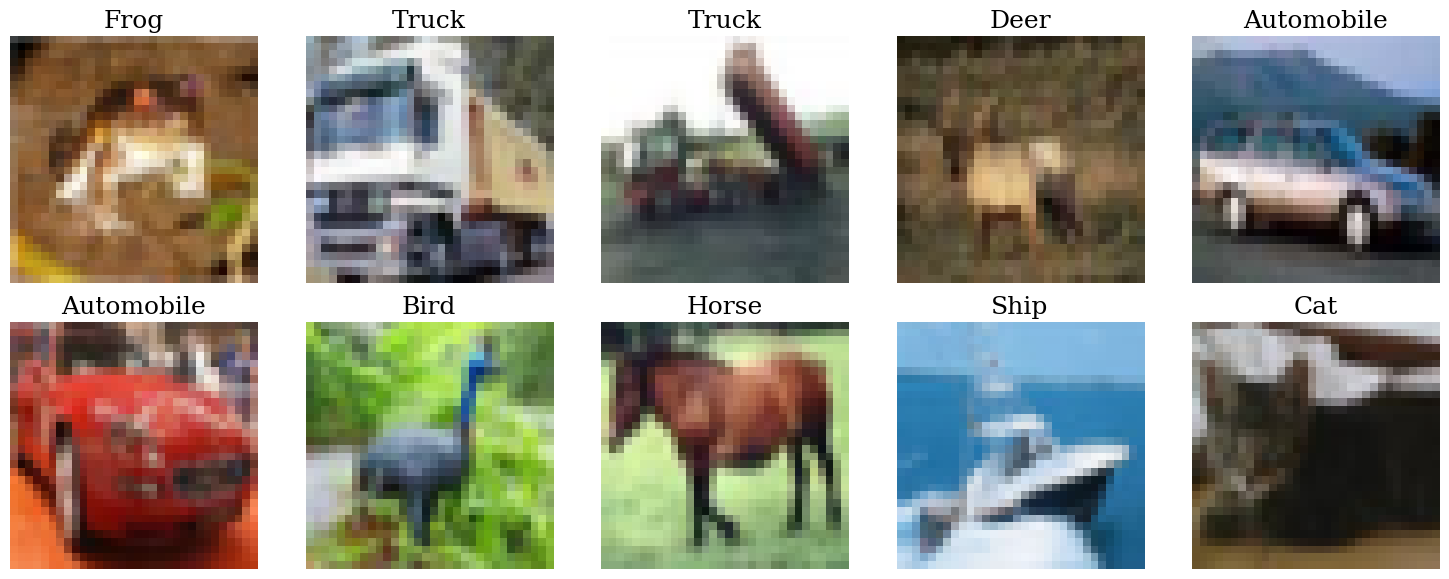

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_cifar10.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
input_shape=(32, 32, 3)
y_train_cat = tf.keras.utils.to_categorical(
    y_train,
    num_classes=10
)

y_test_cat = tf.keras.utils.to_categorical(
    y_test,
    num_classes=10
)

print("Training labels:", y_train_cat.shape)
print("Testing labels:", y_test_cat.shape)

Training labels: (50000, 10)
Testing labels: (10000, 10)


In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

print("VGG16 loaded successfully.")
print("Total layers:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 loaded successfully.
Total layers: 19


In [ ]:
base_model.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Trainable layers: 0


In [ ]:
base_model.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))
print("Total layers:", len(base_model.layers))

Trainable layers: 0
Total layers: 19


In [ ]:
model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
start_time = time.time()

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=32,
    epochs=10,
    verbose=1
)

training_time = time.time() - start_time

print("\nTraining Time:")
print(f"{training_time:.2f} seconds")
print(f"{training_time / 60:.2f} minutes")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.5296 - loss: 1.3445 - val_accuracy: 0.5673 - val_loss: 1.2313
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5896 - loss: 1.1673 - val_accuracy: 0.5859 - val_loss: 1.1778
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6106 - loss: 1.1066 - val_accuracy: 0.6040 - val_loss: 1.1420
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6303 - loss: 1.0536 - val_accuracy: 0.6022 - val_loss: 1.1436
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6429 - loss: 1.0137 - val_accuracy: 0.6116 - val_loss: 1.1056
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6586 - loss: 0.9746 - val_accuracy: 0.6018 - val_loss: 1.1167
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6685 - loss: 0.9439 - val_accuracy: 0.6081 - val_loss: 1.1315
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6786 - 

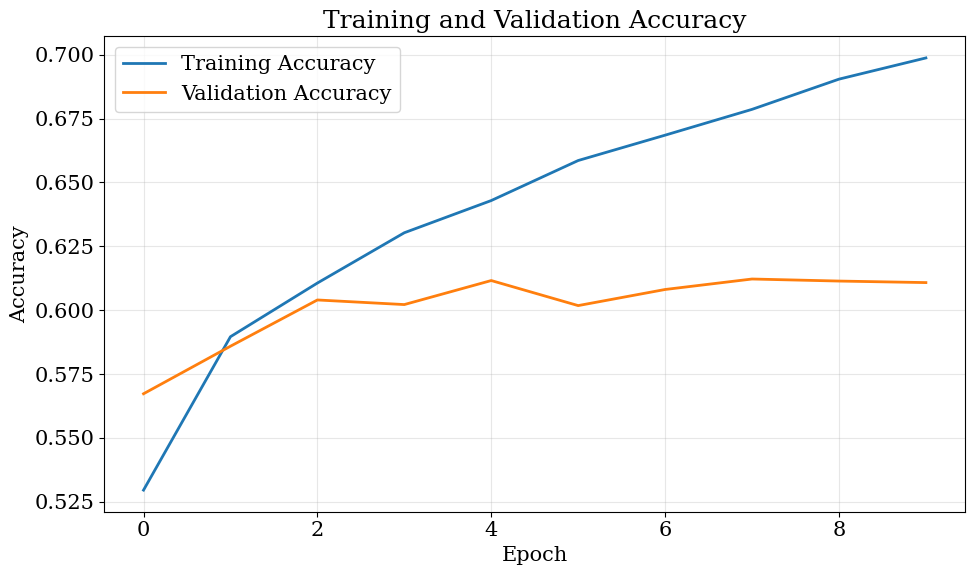

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

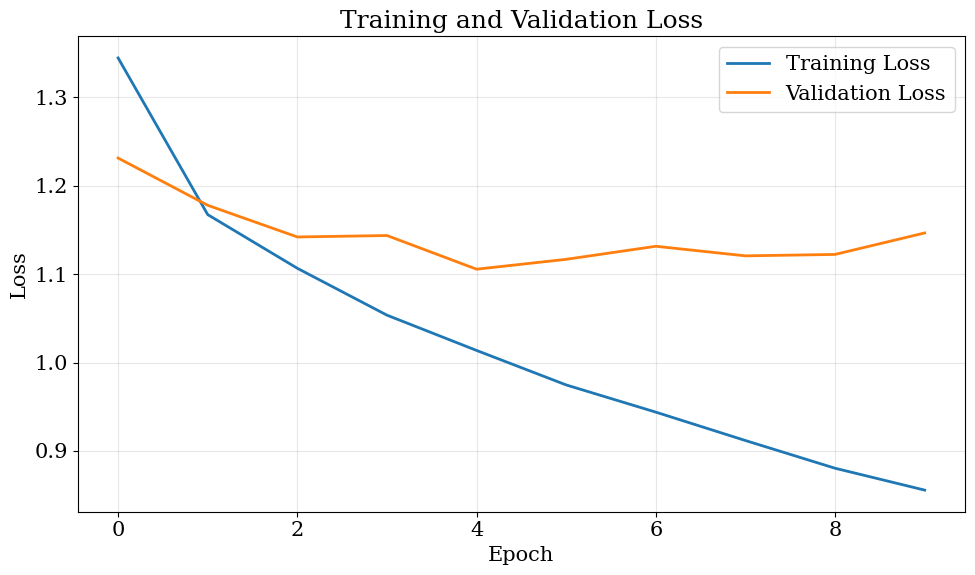

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
# Keep all layers frozen initially
base_model.trainable = True

# Freeze all layers except the last convolutional block
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Check trainable layers
for layer in base_model.layers:
    print(
        layer.name,
        "Trainable:" if layer.trainable else "Frozen"
    )

input_layer Frozen
block1_conv1 Frozen
block1_conv2 Frozen
block1_pool Frozen
block2_conv1 Frozen
block2_conv2 Frozen
block2_pool Frozen
block3_conv1 Frozen
block3_conv2 Frozen
block3_conv3 Frozen
block3_pool Frozen
block4_conv1 Frozen
block4_conv2 Frozen
block4_conv3 Frozen
block4_pool Frozen
block5_conv1 Trainable:
block5_conv2 Trainable:
block5_conv3 Trainable:
block5_pool Trainable:


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
start_finetuning_time = time.time()

fine_tune_history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=32,
    epochs=5,
    verbose=1
)

fine_tuning_time = time.time() - start_finetuning_time

print("\nFine-tuning Time:")
print(f"{fine_tuning_time:.2f} seconds")
print(f"{fine_tuning_time / 60:.2f} minutes")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6499 - loss: 1.0031 - val_accuracy: 0.6766 - val_loss: 0.9328
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7349 - loss: 0.7557 - val_accuracy: 0.7122 - val_loss: 0.8439
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7765 - loss: 0.6258 - val_accuracy: 0.7149 - val_loss: 0.8446
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8151 - loss: 0.5130 - val_accuracy: 0.7382 - val_loss: 0.8042
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.8512 - loss: 0.4114 - val_accuracy: 0.7453 - val_loss: 0.8099

Fine-tuning Time:
117.64 seconds
1.96 minutes


In [ ]:
# Generate predictions
y_pred_prob = model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Testing Accuracy : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")

Testing Accuracy : 0.7453
Precision        : 0.7489
Recall           : 0.7453
F1-score         : 0.7459


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.78      0.82      0.80      1000
  Automobile       0.85      0.83      0.84      1000
        Bird       0.65      0.75      0.69      1000
         Cat       0.56      0.57      0.56      1000
        Deer       0.70      0.69      0.70      1000
         Dog       0.67      0.61      0.64      1000
        Frog       0.77      0.79      0.78      1000
       Horse       0.80      0.80      0.80      1000
        Ship       0.91      0.77      0.84      1000
       Truck       0.80      0.81      0.81      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



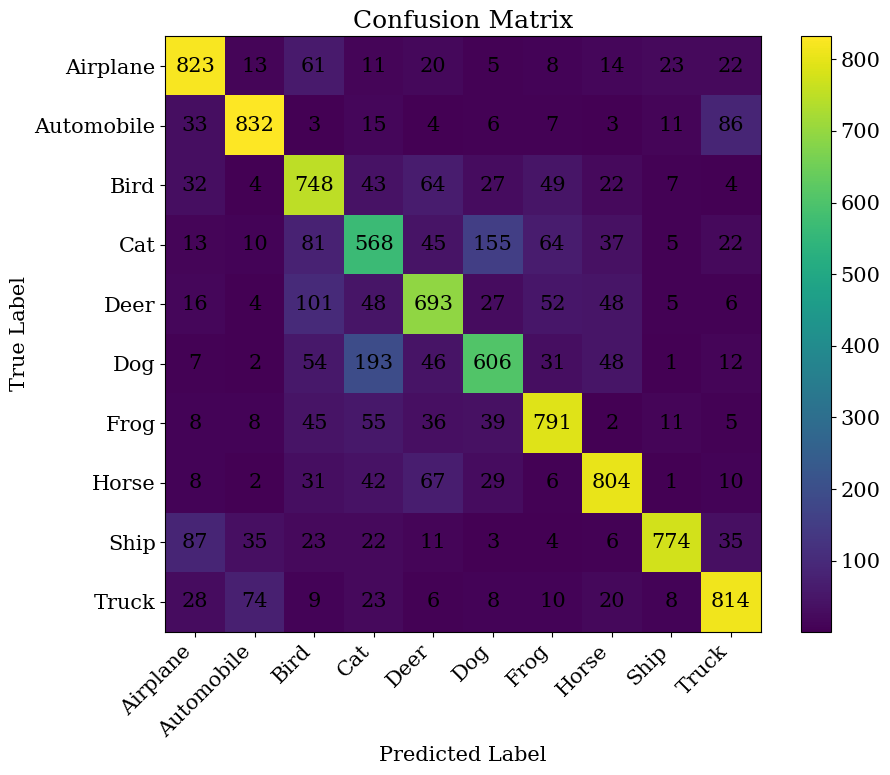

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

# Add values inside cells
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
training_accuracy = history.history["accuracy"][-1]
testing_accuracy = accuracy

total_params = model.count_params()


print(f"Training Accuracy : {training_accuracy:.4f}")
print(f"Testing Accuracy  : {testing_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Training Time     : {training_time:.2f} seconds")
print(f"Total Parameters  : {total_params:,}")

Training Accuracy : 0.6987
Testing Accuracy  : 0.7453
Precision         : 0.7489
Recall            : 0.7453
F1-score          : 0.7459
Training Time     : 162.93 seconds
Total Parameters  : 14,848,586



EXPERIMENT 1
Learning Rate : 0.0001
Batch Size    : 32
Optimizer     : Adam
Dense Units   : 128
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.4070 - loss: 1.7285 - val_accuracy: 0.4932 - val_loss: 1.4843
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5208 - loss: 1.3975 - val_accuracy: 0.5280 - val_loss: 1.3655
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5485 - loss: 1.3128 - val_accuracy: 0.5476 - val_loss: 1.3120
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5644 - loss: 1.2655 - val_accuracy: 0.5547 - val_loss: 1.2800
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5753 - loss: 1.2335 - val_accuracy: 0.5603 - val_loss: 1.2566
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5835 - loss: 1.2086 - val_accuracy: 0.5669 - val_loss: 1.2417
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5898 - loss: 1.1901 - val_accuracy: 0.572

,Learning Rate,Batch Size,Optimizer,Dense Units,Val. Accuracy,Final Val. Accuracy,Time (s)
0,0.0001,32,Adam,128,0.5836,0.5836,168.181901
1,0.0010,64,Adam,128,0.6168,0.6168,136.712349
2,0.0001,64,SGD,256,0.2698,0.2698,132.369776
3,0.0010,16,SGD,128,0.5160,0.5160,239.348330
4,0.0001,16,Adam,256,0.5957,0.5957,240.094270


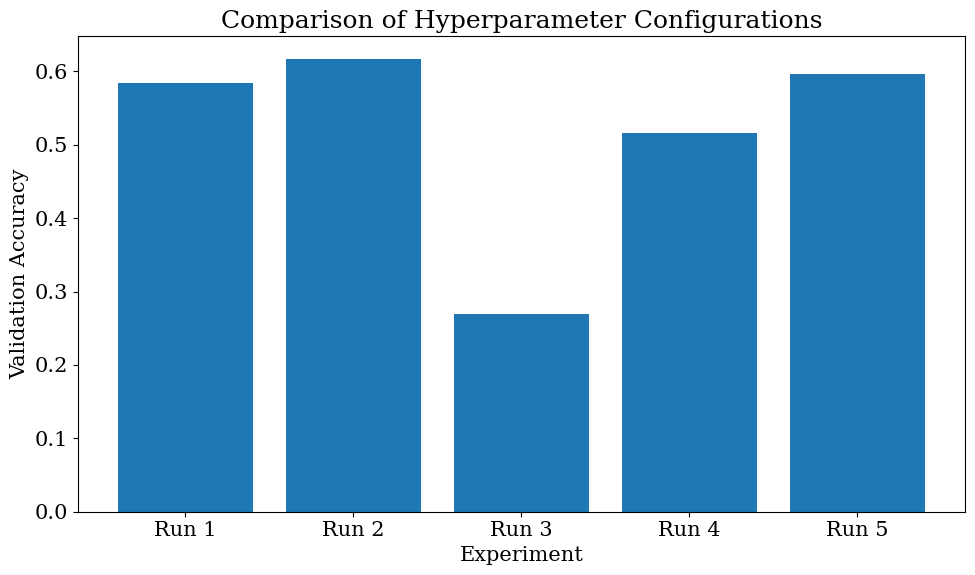

In [ ]:
import time
import tensorflow as tf
from tensorflow.keras.applications import VGG16

# Five different hyperparameter combinations
experiments = [
    {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "optimizer": "Adam",
        "dense_units": 128
    },
    {
        "learning_rate": 0.001,
        "batch_size": 64,
        "optimizer": "Adam",
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 64,
        "optimizer": "SGD",
        "dense_units": 256
    },
    {
        "learning_rate": 0.001,
        "batch_size": 16,
        "optimizer": "SGD",
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 16,
        "optimizer": "Adam",
        "dense_units": 256
    }
]

results = []

for i, config in enumerate(experiments, start=1):

    print("\n" + "=" * 60)
    print(f"EXPERIMENT {i}")
    print("=" * 60)

    print(f"Learning Rate : {config['learning_rate']}")
    print(f"Batch Size    : {config['batch_size']}")
    print(f"Optimizer     : {config['optimizer']}")
    print(f"Dense Units   : {config['dense_units']}")

    # Fresh VGG16 model
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(32, 32, 3)
    )

    # Freeze convolutional base
    base_model.trainable = False

    # Build fresh model
    experiment_model = tf.keras.Sequential([
        base_model,

        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            config["dense_units"],
            activation="relu"
        ),

        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Select optimizer
    if config["optimizer"] == "Adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        )
    else:
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=config["learning_rate"]
        )

    # Compile
    experiment_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Training
    start_time = time.time()

    history_exp = experiment_model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_test, y_test_cat),
        batch_size=config["batch_size"],
        epochs=10,
        verbose=1
    )

    training_time = time.time() - start_time

    # Best validation accuracy
    best_val_accuracy = max(
        history_exp.history["val_accuracy"]
    )

    # Final validation accuracy
    final_val_accuracy = (
        history_exp.history["val_accuracy"][-1]
    )

    results.append({
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Optimizer": config["optimizer"],
        "Dense Units": config["dense_units"],
        "Val. Accuracy": best_val_accuracy,
        "Final Val. Accuracy": final_val_accuracy,
        "Time (s)": training_time
    })

    print(f"\nBest Validation Accuracy : {best_val_accuracy:.4f}")
    print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
    print(f"Training Time            : {training_time:.2f} seconds")

    import pandas as pd

results_df = pd.DataFrame(results)

print("\nFINAL HYPERPARAMETER STUDY")
display(results_df)

# Plot validation accuracy for the five hyperparameter configurations

plt.figure(figsize=(10, 6))

experiment_labels = [
    "Run 1",
    "Run 2",
    "Run 3",
    "Run 4",
    "Run 5"
]

plt.bar(
    experiment_labels,
    results_df["Val. Accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Validation Accuracy")
plt.title("Comparison of Hyperparameter Configurations")

plt.tight_layout()

plt.savefig(
    "hyperparameter_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()